# SpaceX Falcon 9 First Stage Landing Prediction

## Exploratory Data Analysis with Visualization
This notebook uses visual exploration to understand how mission features relate to first-stage landing success.

## Guiding Questions
- How does payload mass relate to landing success?
- Which launch sites show stronger landing performance?
- How do orbit types influence outcomes?
- How has landing success changed over time?

## 1. Import Required Libraries
Import core libraries for data processing and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## 2. Load and Validate the Dataset
Load the cleaned launch dataset and perform basic quality checks.

In [2]:
spacex_df = pd.read_csv('../data/processed/spacex_launch_data_clean.csv')

# Keep rows with known landing labels and enforce analysis-friendly dtypes.
spacex_df = spacex_df[spacex_df['Class'].notna()].copy()
spacex_df['Class'] = spacex_df['Class'].astype(int)
spacex_df['LaunchSite'] = spacex_df['LaunchSite'].astype(str)
spacex_df['Latitude'] = spacex_df['Latitude'].astype(float)
spacex_df['Longitude'] = spacex_df['Longitude'].astype(float)

In [3]:
# Check the shape and basic info of the dataset
print(f"Dataset shape: {spacex_df.shape}")
print(f"\nColumn names and types:")
print(spacex_df.dtypes)
print(f"\nMissing values:")
print(spacex_df.isnull().sum())

Dataset shape: (90, 18)

Column names and types:
FlightNumber        int64
Date               object
BoosterVersion     object
PayloadMass       float64
Orbit              object
LaunchSite         object
Outcome            object
Flights             int64
GridFins             bool
Reused               bool
Legs                 bool
LandingPad         object
Block             float64
ReusedCount         int64
Serial             object
Longitude         float64
Latitude          float64
Class               int32
dtype: object

Missing values:
FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
Class              0
dtype: int64


In [4]:
# Display first few rows of the dataset
spacex_df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,6,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,8,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,10,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,11,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,12,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## 3. Visual Exploration
### 3.1 Flight Number vs Payload Mass
Assess how payload mass varies by flight and whether outcomes differ by success class.

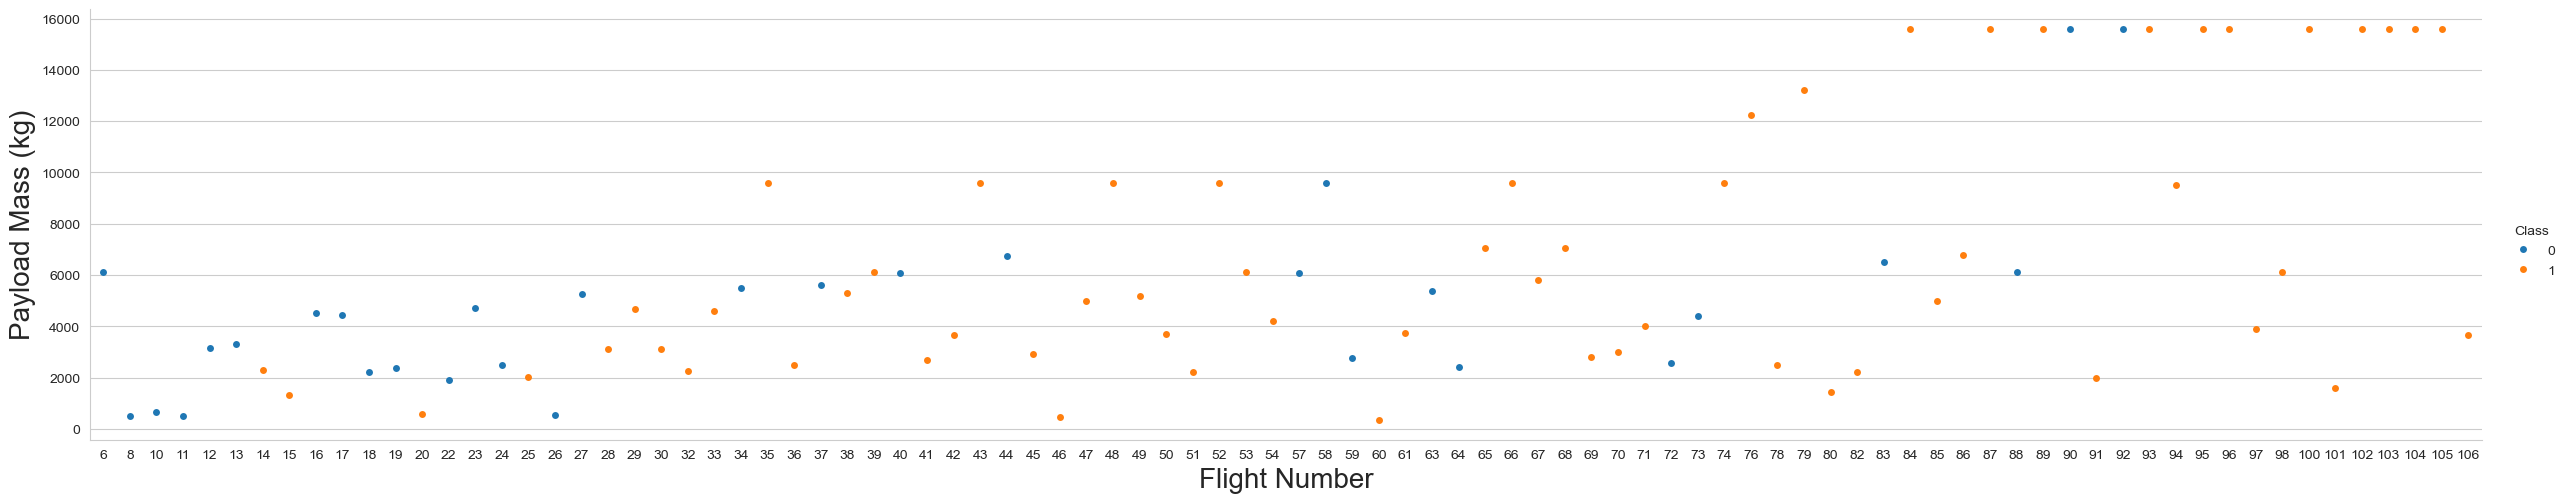

In [5]:
# Visualize the relationship between Flight Number and Payload Mass
# Color-coded by landing outcome (Class: 1=Success, 0=Failure)
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=spacex_df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Payload Mass (kg)", fontsize=20)
plt.show()

### 3.2 Flight Number vs Launch Site
Review launch-site usage across flights and compare landing outcomes.

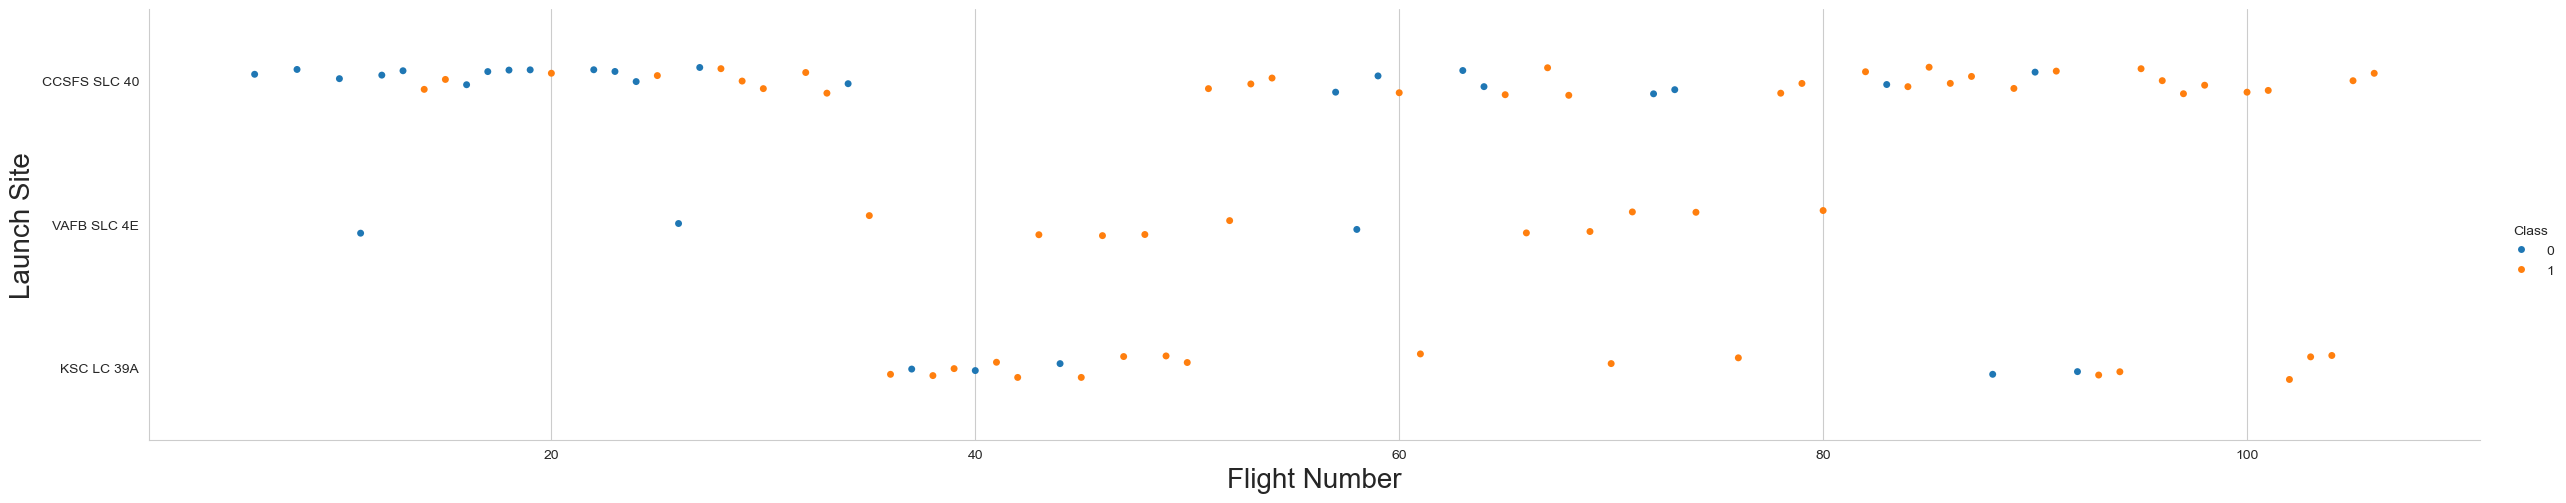

In [6]:
# Visualize the relationship between Flight Number and Launch Site
# Shows which launch sites are used over time and their success rates
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=spacex_df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.show()

### 3.3 Payload Mass vs Launch Site
Compare payload ranges by site and inspect associated landing outcomes.

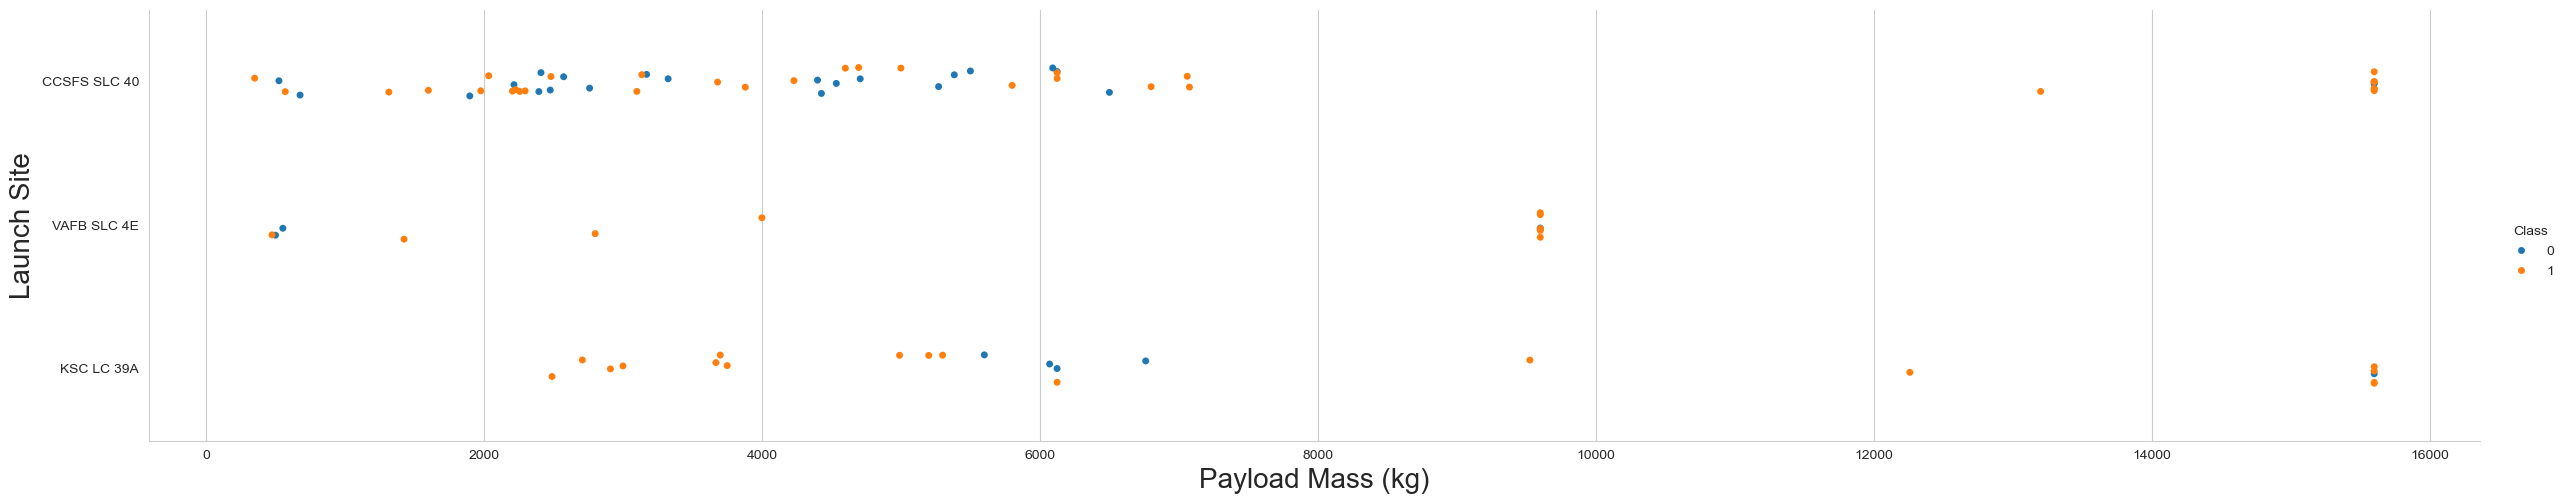

In [7]:
# Visualize the relationship between Payload Mass and Launch Site
# Analyze how different launch sites handle varying payload masses
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=spacex_df, aspect=5)
plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.show()

### 3.4 Landing Success by Orbit Type
Evaluate whether some orbit classes are linked to higher landing success.

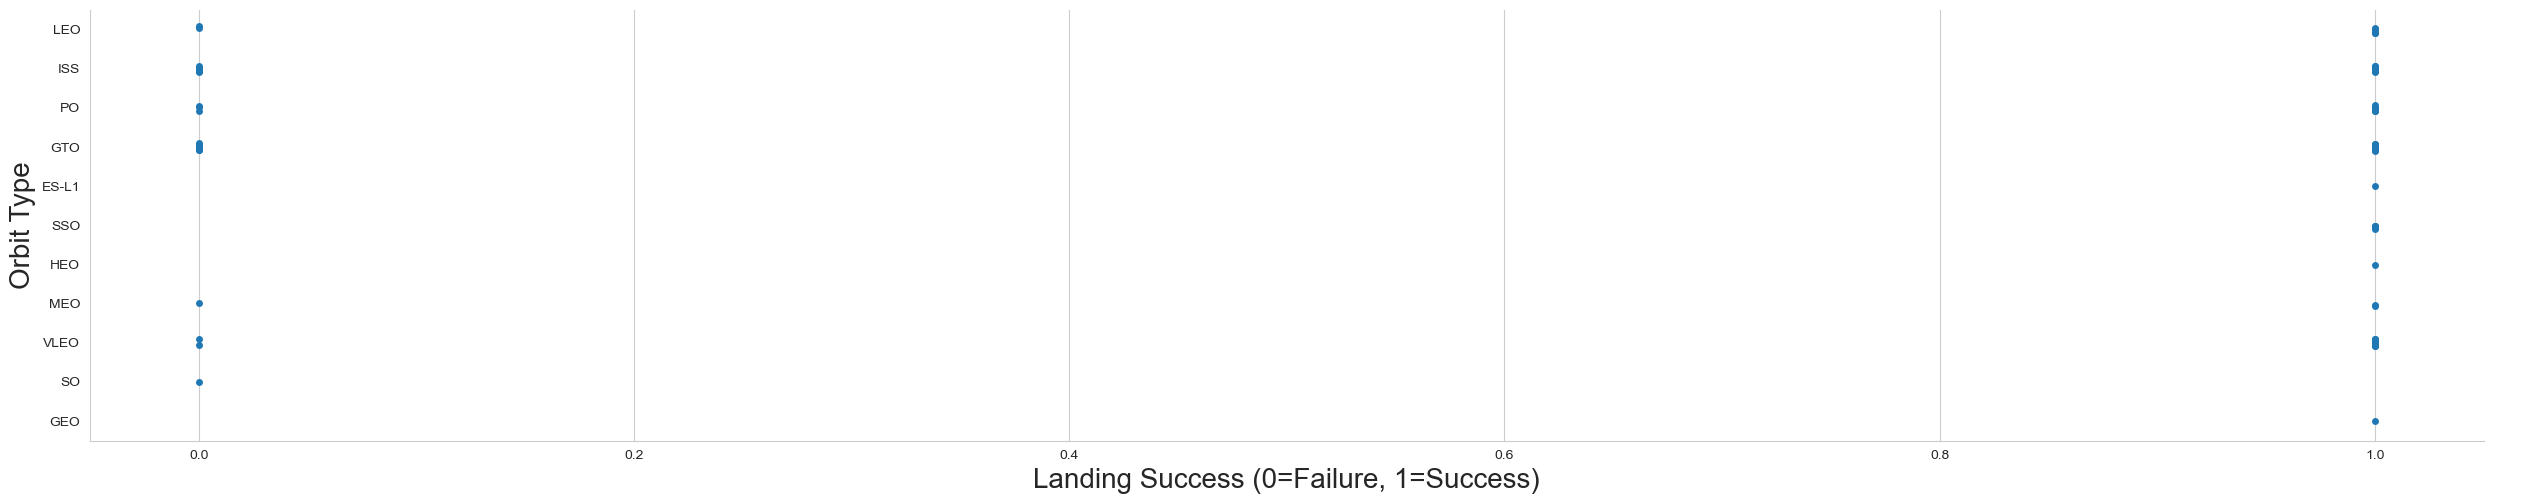

In [8]:
# Visualize the success rate distribution for each orbit type
# Shows which orbits have higher success rates for first stage landing
sns.catplot(y="Orbit", x="Class", data=spacex_df, aspect=5)
plt.xlabel("Landing Success (0=Failure, 1=Success)", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.show()

### 3.5 Flight Number vs Orbit Type
Track how orbit profiles evolved as mission count increased.

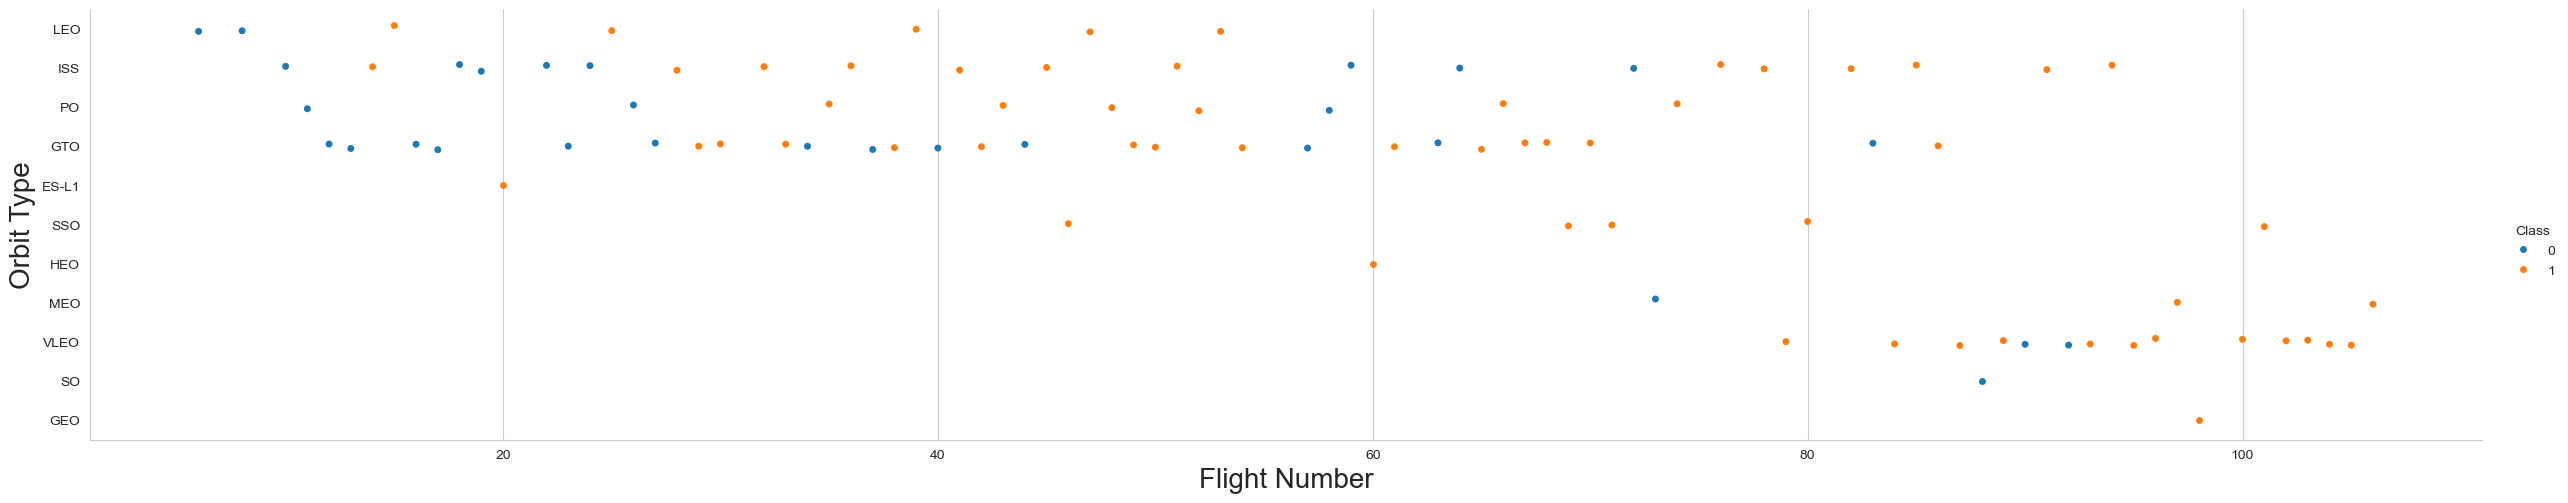

In [9]:
# Visualize the relationship between Flight Number and Orbit Type
# Track how SpaceX missions to different orbits have evolved over time
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=spacex_df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.show()

### 3.6 Payload Mass vs Orbit Type
Inspect payload distribution across orbits and its link to landing results.

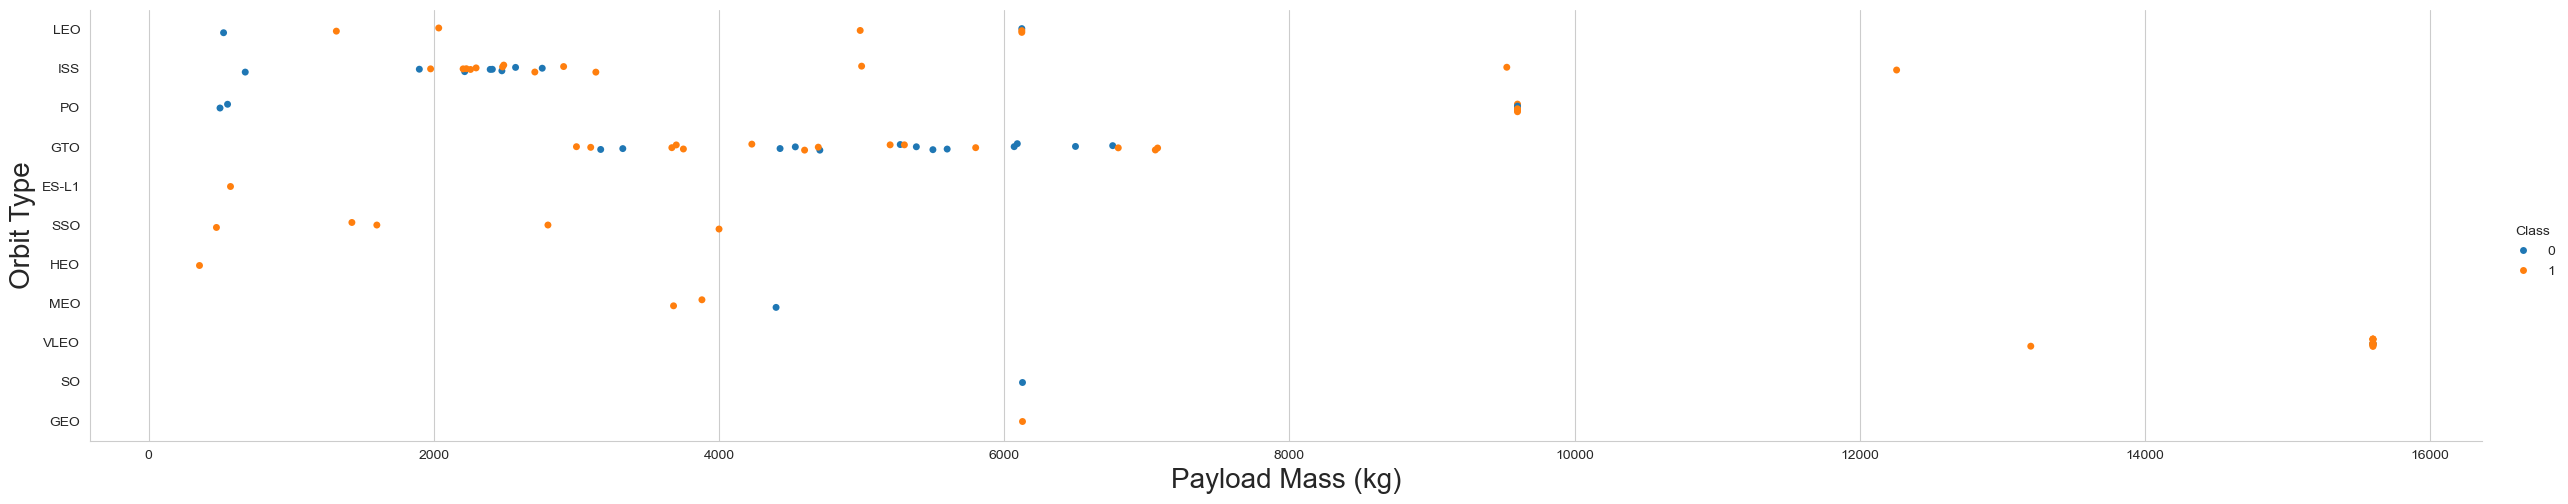

In [10]:
# Visualize the relationship between Payload Mass and Orbit Type
# Examine payload capacities for different orbit missions
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=spacex_df, aspect=5)
plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.show()

### 3.7 Yearly Landing Success Trend
Measure how average landing success changed over calendar years.

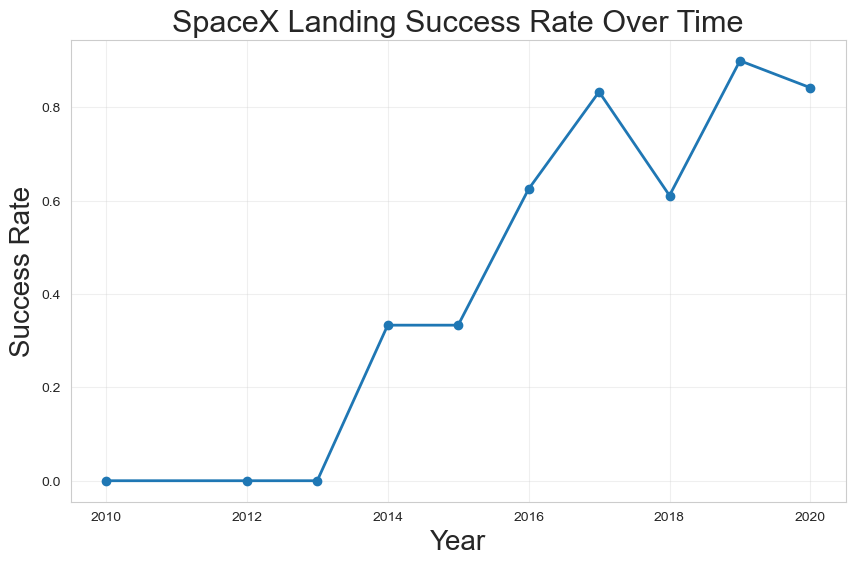

In [11]:
# Analyze the yearly trend of landing success rates
# Extract year from date and calculate average success rate per year
spacex_df['Year'] = pd.DatetimeIndex(spacex_df['Date']).year
yearly_success = spacex_df.groupby(['Year'])['Class'].mean().reset_index()

# Plot the success rate trend over years
plt.figure(figsize=(10, 6))
plt.plot(yearly_success['Year'], yearly_success['Class'], marker='o', linewidth=2)
plt.xlabel('Year', fontsize=20)
plt.ylabel('Success Rate', fontsize=20)
plt.title('SpaceX Landing Success Rate Over Time', fontsize=22)
plt.grid(True, alpha=0.3)
plt.show()

## 4. Feature Engineering for Machine Learning
Select and transform model-ready features for the prediction notebook.

In [12]:
# Select relevant features for machine learning model
# Include both numerical and categorical features that may influence landing success
features = spacex_df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 
                      'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 
                      'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,6,6123.547647,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,8,525.000000,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,10,677.000000,ISS,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,11,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,12,3170.000000,GTO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### 4.1 Create Dummy Variables
Encode categorical features with one-hot encoding for model compatibility.

In [13]:
# Convert categorical variables to numerical using one-hot encoding
# drop_first=True removes one dummy variable to avoid multicollinearity
features = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'], 
                          drop_first=True)
features.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_GEO,Orbit_GTO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,6,6123.547647,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,8,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,10,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,11,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,12,3170.000000,1,False,False,False,1.0,0,False,True,...,False,False,False,False,False,False,False,False,False,False


### 4.2 Convert Features to float64
Standardize feature dtypes for downstream machine learning workflows.

In [14]:
# Convert all features to float64 data type for ML algorithm compatibility
# Ensures consistent numerical format across all features
features = features.astype('float64')
features.dtypes

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 76, dtype: object

### 4.3 Export Feature Dataset
Save the engineered feature matrix for model training and evaluation.

In [15]:
features.to_csv('../data/processed/spacex_features.csv', index=False)
print("Features successfully exported to '../data/processed/spacex_features.csv'")

Features successfully exported to '../data/processed/spacex_features.csv'


## Summary
This visualization EDA notebook:

- Examined relationships among payload mass, launch site, orbit, and landing success
- Identified temporal improvements in landing performance
- Prepared model-ready features with encoding and dtype standardization
- Exported the final features dataset to `../data/processed/spacex_features.csv`

These outputs feed directly into the machine learning stage of the project.